In [59]:
import pandas as pd
import seaborn as sns
import numpy as np


In [60]:
df =  pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [61]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [62]:
print(f"Rows :  {df.shape[0]} and Coloumns : {df.shape[1]}")

Rows :  7043 and Coloumns : 21


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [64]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df.drop(columns="customerID",inplace=True)

<Axes: xlabel='Churn'>

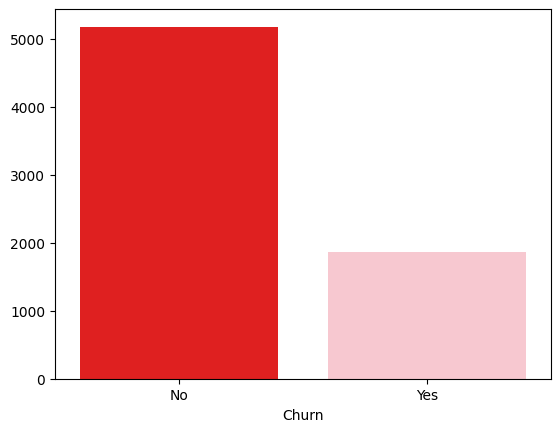

In [65]:
x = df["Churn"].value_counts()
c = ["red","pink"]
sns.barplot(x= x.index,y=x.values,palette=c,hue=x.index)

In [66]:
print(df["TotalCharges"].isnull().sum())
df["TotalCharges"].fillna(df["TotalCharges"].mean(),inplace=True)

11


C:\Users\Zainch-032\AppData\Local\Temp\ipykernel_7544\2725394825.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].mean(),inplace=True)


In [67]:
df.groupby("Churn")[["MonthlyCharges","TotalCharges","tenure"]].mean()

,MonthlyCharges,TotalCharges,tenure
Churn,,,
No,61.265124,2554.765772,37.569965
Yes,74.441332,1531.796094,17.979133


In [68]:
bins = [0,6,30,50,72]
labels = ["0-6","7-30","31-50","51-72"]
df["ten_bins"] = pd.cut(df["tenure"],bins=bins,labels=labels)
pd.crosstab(df["Churn"],df["ten_bins"])

ten_bins,0-6,7-30,31-50,51-72
Churn,,,,
No,686,1519,1041,1917
Yes,784,641,256,188


Two key points:

**1. Churn is heavily front-loaded in early tenure — and drops sharply after.**
- In the 0-6 month bin: 784 churned vs 686 stayed → **churn rate ~53%**, more than half leave almost immediately.
- By 51-72 months: only 188 churned vs 1917 stayed → **churn rate ~9%**.
This confirms the tenure hypothesis numerically — the first few months are the highest-risk window, and loyalty strongly compounds after that.
